# Trinity Types

- Fronts (FRONT)
- Extratropical Cyclones (ETC)
- Atmospheric Rivers (AR)
- Tropical Cyclones (TC)
- North American Monsoon (NAM)

Alshehri et al (2024)
https://journals.ametsoc.org/view/journals/hydr/25/12/JHM-D-24-0024.1.xml

In [1]:
import os
import pandas as pd
import geopandas as gpd

In [2]:
ghcnd_metadata_file = "/workspaces/stormhub/data/0_source/ghcnd/ghcnd_stations.parquet"
ghcnd_database_file = "/workspaces/stormhub/data/0_source/ghcnd/all_stations.parquet"
transposition_file = "/workspaces/stormhub/data/0_source/transposition/trinity_transpo_area_v01_valid.geojson"
huc4_file = "/workspaces/stormhub/data/0_source/huc04/trinity.shp"

In [3]:
stations_gdf = gpd.read_parquet(ghcnd_metadata_file)
stations_gdf

,SITE_ID,LATITUDE,LONGITUDE,ELEVATION,SITE_NAME,geometry
0,ACW00011604,17.1167,-61.7833,10.1,ST JOHNS COOLIDGE FLD,POINT (-61.7833 17.1167)
1,ACW00011647,17.1333,-61.7833,19.2,ST JOHNS,POINT (-61.7833 17.1333)
2,AE000041196,25.3330,55.5170,34.0,SHARJAH INTER. AIRP,POINT (55.517 25.333)
3,AEM00041194,25.2550,55.3640,10.4,DUBAI INTL,POINT (55.364 25.255)
4,AEM00041217,24.4330,54.6510,26.8,ABU DHABI INTL,POINT (54.651 24.433)
...,...,...,...,...,...,...
129652,ZI000067969,21.0500,29.3670,861.0,WEST NICHOLSON,POINT (29.367 21.05)
129653,ZI000067975,20.0670,30.8670,1095.0,MASVINGO,POINT (30.867 20.067)
129654,ZI000067977,21.0170,31.5830,430.0,BUFFALO RANGE,POINT (31.583 21.017)
129655,ZI000067983,20.2000,32.6160,1132.0,CHIPINGE,POINT (32.616 20.2)


In [4]:
transposition_gdf = gpd.read_file(transposition_file)
transposition_gdf = transposition_gdf.to_crs(stations_gdf.crs)
transposition_gdf

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/envs/stormhub-base/share/proj failed


,geometry
0,"POLYGON ((-95.43888 28.92048, -95.43888 28.928..."


In [5]:
huc4_gdf = gpd.read_file(huc4_file)
huc4_gdf = huc4_gdf.to_crs(stations_gdf.crs)
huc4_gdf

,areaacres,areasqkm,states,huc4,name,globalid,geometry
0,11486295.28,46483.43,TX,1203,Trinity,{99109a65-08f9-4296-b705-fb9c3f609b5a},"POLYGON ((-97.39518 33.73452, -97.39443 33.734..."


In [6]:
# find stations within transposition area
merged_stations_gdf = gpd.sjoin(stations_gdf, transposition_gdf, how="inner", predicate="intersects")
merged_stations_gdf

,SITE_ID,LATITUDE,LONGITUDE,ELEVATION,SITE_NAME,geometry,index_right
54500,US1ALAT0002,32.4756,-86.4393,106.1,PRATTVILLE 1.1 NNE,POINT (-86.4393 32.4756),0
54501,US1ALAT0010,32.4262,-86.5390,95.1,PRATTVILLE 5.9 WSW,POINT (-86.539 32.4262),0
54502,US1ALAT0013,32.6444,-86.4302,268.2,DEATSVILLE 3.4 NW,POINT (-86.4302 32.6444),0
54503,US1ALAT0014,32.4825,-86.4854,100.3,PRATTVILLE 2.7 WNW,POINT (-86.4854 32.4825),0
54504,US1ALAT0022,32.4824,-86.5252,75.3,PRATTVILLE 4.8 WNW,POINT (-86.5252 32.4824),0
...,...,...,...,...,...,...,...
128647,USW00093985,32.7817,-98.0603,287.1,MINERAL WELLS AP,POINT (-98.0603 32.7817),0
128649,USW00093987,31.2358,-94.7547,87.2,LUFKIN ANGELINA CO AP,POINT (-94.7547 31.2358),0
128650,USW00093988,34.1797,-91.9344,62.2,PINE BLUFF GRIDER FLD,POINT (-91.9344 34.1797),0
128654,USW00093992,33.2208,-92.8142,78.0,EL DORADO GOODWIN FLD,POINT (-92.8142 33.2208),0


In [7]:
master_df = pd.read_parquet(ghcnd_database_file, filters=[("station", "in", merged_stations_gdf["SITE_ID"].tolist())])
master_df["cause_1"].fillna("Others", inplace=True)

/tmp/ipykernel_23500/3994891200.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_df["cause_1"].fillna("Others", inplace=True)


In [8]:
unique_stations = master_df.station.unique().tolist()
merged_stations_gdf = merged_stations_gdf[merged_stations_gdf["SITE_ID"].isin(unique_stations)]
merged_stations_gdf

,SITE_ID,LATITUDE,LONGITUDE,ELEVATION,SITE_NAME,geometry,index_right
101752,USC00010140,32.2322,-87.4103,53.3,ALBERTA,POINT (-87.4103 32.2322),0
101758,USC00010252,31.3072,-86.5225,76.2,ANDALUSIA 3 W,POINT (-86.5225 31.3072),0
101778,USC00010583,30.8839,-87.7853,82.6,BAY MINETTE,POINT (-87.7853 30.8839),0
101781,USC00010655,34.6892,-86.8819,183.8,BELLE MINA 2 N,POINT (-86.8819 34.6892),0
101799,USC00011084,31.0583,-87.0550,25.9,BREWTON 3 SSE,POINT (-87.055 31.0583),0
...,...,...,...,...,...,...,...
128632,USW00093919,31.1822,-90.4719,123.4,MCCOMB AP,POINT (-90.4719 31.1822),0
128647,USW00093985,32.7817,-98.0603,287.1,MINERAL WELLS AP,POINT (-98.0603 32.7817),0
128649,USW00093987,31.2358,-94.7547,87.2,LUFKIN ANGELINA CO AP,POINT (-94.7547 31.2358),0
128650,USW00093988,34.1797,-91.9344,62.2,PINE BLUFF GRIDER FLD,POINT (-91.9344 34.1797),0


In [9]:
storm_types = {}
for station in unique_stations:
    subset = master_df[master_df["station"] == station].copy()
    counts = subset["cause_1"].value_counts()
    percents = (counts / counts.sum() * 100).round(2)
    storm_types[station] = {
        "counts": counts.to_dict(),
        "percent": percents.to_dict(),
    }
    print(f"Station {station} has {len(subset)} records and {len(counts)} storm types.")

Station USC00010140 has 23922 records and 4 storm types.
Station USC00010252 has 24848 records and 4 storm types.
Station USC00010583 has 25262 records and 4 storm types.
Station USC00010655 has 25007 records and 4 storm types.
Station USC00011084 has 23828 records and 4 storm types.
Station USC00011566 has 24235 records and 4 storm types.
Station USC00011694 has 23189 records and 4 storm types.
Station USC00011725 has 23199 records and 4 storm types.
Station USC00012245 has 24128 records and 4 storm types.
Station USC00012813 has 25471 records and 4 storm types.
Station USC00013160 has 25219 records and 4 storm types.
Station USC00013511 has 24155 records and 4 storm types.
Station USC00013519 has 24544 records and 4 storm types.
Station USC00013620 has 24909 records and 4 storm types.
Station USC00013761 has 23783 records and 4 storm types.
Station USC00014502 has 24023 records and 4 storm types.
Station USC00014619 has 24209 records and 4 storm types.
Station USC00015121 has 24879 r

In [10]:
# Add storm-type percentages to stations_gdf
percent_dict = {station: vals["percent"] for station, vals in storm_types.items()}
percent_df = (
    pd.DataFrame.from_dict(percent_dict, orient="index")
    .reset_index()
    .rename(columns={"index": "SITE_ID"})
)
points_df = stations_gdf.merge(percent_df, on="SITE_ID", how="left")
points_df = points_df.dropna(subset=["FRONT","ETC","TC"])
points_gdf = gpd.GeoDataFrame(points_df, geometry="geometry", crs="EPSG:4326")
print(f"Number of GHCNd stations: {len(points_gdf)}")
points_gdf

Number of GHCNd stations: 320


,SITE_ID,LATITUDE,LONGITUDE,ELEVATION,SITE_NAME,geometry,Others,FRONT,ETC,TC
101752,USC00010140,32.2322,-87.4103,53.3,ALBERTA,POINT (-87.4103 32.2322),54.17,41.00,3.88,0.95
101758,USC00010252,31.3072,-86.5225,76.2,ANDALUSIA 3 W,POINT (-86.5225 31.3072),53.36,42.08,3.41,1.16
101778,USC00010583,30.8839,-87.7853,82.6,BAY MINETTE,POINT (-87.7853 30.8839),53.23,42.36,3.25,1.16
101781,USC00010655,34.6892,-86.8819,183.8,BELLE MINA 2 N,POINT (-86.8819 34.6892),50.03,43.81,5.54,0.62
101799,USC00011084,31.0583,-87.0550,25.9,BREWTON 3 SSE,POINT (-87.055 31.0583),55.43,40.04,3.36,1.17
...,...,...,...,...,...,...,...,...,...,...
128632,USW00093919,31.1822,-90.4719,123.4,MCCOMB AP,POINT (-90.4719 31.1822),53.32,42.11,3.44,1.13
128647,USW00093985,32.7817,-98.0603,287.1,MINERAL WELLS AP,POINT (-98.0603 32.7817),46.97,37.15,15.48,0.39
128649,USW00093987,31.2358,-94.7547,87.2,LUFKIN ANGELINA CO AP,POINT (-94.7547 31.2358),52.21,41.25,5.69,0.85
128650,USW00093988,34.1797,-91.9344,62.2,PINE BLUFF GRIDER FLD,POINT (-91.9344 34.1797),52.19,41.21,6.00,0.60


In [11]:
points_gdf.describe()

,LATITUDE,LONGITUDE,ELEVATION,Others,FRONT,ETC,TC
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,32.638507,-91.179770,111.501563,51.043969,41.670969,6.491000,0.794469
std,1.534849,4.130693,78.840045,2.928447,1.737984,3.536431,0.308359
min,28.984400,-99.301100,-0.900000,42.830000,35.350000,2.790000,0.300000
25%,31.465075,-94.764775,57.750000,49.607500,40.447500,3.997500,0.550000
50%,32.732500,-91.124900,97.050000,51.465000,41.995000,5.520000,0.730000
75%,33.911925,-88.519750,147.650000,53.062500,42.892500,7.082500,1.000000
max,35.621400,-82.127800,441.400000,57.050000,46.600000,17.540000,1.710000


In [12]:
import numpy as np
import folium
from folium.features import DivIcon

# Helper to build an SVG pie chart as a DivIcon
def pie_svg(values, colors, size=36):
    """Generate an SVG pie chart as a string."""
    total = float(sum(values))
    if total == 0:
        values = [1, 1, 1]
        total = 3.0
    angles = np.cumsum([0] + [v / total * 360 for v in values])
    r = size / 2
    svg = [f'<svg width="{size}" height="{size}" viewBox="0 0 {size} {size}" xmlns="http://www.w3.org/2000/svg">']
    for i in range(len(values)):
        start = angles[i]
        end = angles[i + 1]
        # Convert angles to radians (start at 12 o'clock)
        start_rad = np.deg2rad(start - 90)
        end_rad = np.deg2rad(end - 90)
        x1, y1 = r + r * np.cos(start_rad), r + r * np.sin(start_rad)
        x2, y2 = r + r * np.cos(end_rad), r + r * np.sin(end_rad)
        large_arc = 1 if (end - start) > 180 else 0
        path = (
            f'M {r} {r} L {x1:.3f} {y1:.3f} '
            f'A {r} {r} 0 {large_arc} 1 {x2:.3f} {y2:.3f} Z'
        )
        svg.append(f'<path d="{path}" fill="{colors[i]}" />')
    svg.append('</svg>')
    return ''.join(svg)

# Build map centered on the points
center = [points_gdf.geometry.y.mean(), points_gdf.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=8, tiles="CartoDB positron")

# Add boundaries with hover tooltips (skip geometry-only data)
transpo_fields = [c for c in transposition_gdf.columns if c != "geometry"]
huc4_fields = [c for c in huc4_gdf.columns if c != "geometry"]
transpo_tooltip = folium.GeoJsonTooltip(fields=transpo_fields) if transpo_fields else None
huc4_tooltip = folium.GeoJsonTooltip(fields=huc4_fields) if huc4_fields else None
folium.GeoJson(
    transposition_gdf,
    name="Transpo boundary",
    style_function=lambda x: {"color": "#1f78b4", "weight": 2, "fill": False},
    tooltip=transpo_tooltip
).add_to(m)
folium.GeoJson(
    huc4_gdf,
    name="HUC4 boundary",
    style_function=lambda x: {"color": "#33a02c", "weight": 2, "fill": False},
    tooltip=huc4_tooltip
).add_to(m)

# Add pie charts at each point with hover tooltips
pie_colors = ["#e31a1c", "#ff7f00", "#6a3d9a", "#33a02c",]
point_fields = ["FRONT", "ETC", "TC", "Others"]
for _, row in points_gdf.iterrows():
    values = [row.get("FRONT", 0), row.get("ETC", 0), row.get("TC", 0), row.get("Others", 0)]
    svg = pie_svg(values, pie_colors, size=36)
    tooltip_html = "<br>".join([f"{f}: {row.get(f, '')}" for f in point_fields])
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=DivIcon(html=svg),
        tooltip=tooltip_html
    ).add_to(m)

folium.LayerControl().add_to(m)
m

In [13]:
means = points_gdf.describe().loc["mean", ["FRONT", "ETC", "TC", "Others"]]
stds = points_gdf.describe().loc["std", ["FRONT", "ETC", "TC", "Others"]]
for col in ["FRONT", "ETC", "TC", "Others"]:
    lower_bound = means[col] - 2 * stds[col]
    upper_bound = means[col] + 2 * stds[col]
    print(f"{col}: mean={means[col]:.1f}, std={stds[col]:.1f}, lower={lower_bound:.1f}, upper={upper_bound:.1f}")

FRONT: mean=41.7, std=1.7, lower=38.2, upper=45.1
ETC: mean=6.5, std=3.5, lower=-0.6, upper=13.6
TC: mean=0.8, std=0.3, lower=0.2, upper=1.4
Others: mean=51.0, std=2.9, lower=45.2, upper=56.9


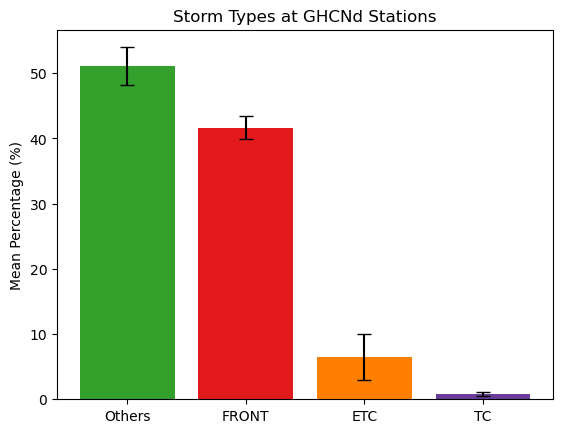

In [14]:
import matplotlib.pyplot as plt
order = means.sort_values(ascending=False).index
plt.bar(order, means[order], yerr=stds[order], capsize=5, color=[pie_colors[list(means.index).index(i)] for i in order])
plt.ylabel("Mean Percentage (%)")
plt.title("Storm Types at GHCNd Stations")
plt.show()